# AI-Powered Emotion Detection from Text

## Internship Project

### Objective
Build a Natural Language Processing (NLP) model capable of detecting emotions from text.

### Emotions Detected
- Sadness
- Joy
- Love
- Anger
- Fear
- Surprise

### Techniques Used
- Text Preprocessing
- TF-IDF Vectorization
- Naive Bayes
- Logistic Regression
- Model Evaluation using Accuracy and F1 Score

In [2]:
from datasets import load_dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\aakan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
dataset = load_dataset("dair-ai/emotion")

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

label_names = dataset["train"].features["label"].names

print("Train Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()
train_df.isnull().sum()

Train Shape: (16000, 2)
Validation Shape: (2000, 2)
Test Shape: (2000, 2)


text     0
label    0
dtype: int64

## Dataset Exploration

Before training a machine learning model, it is important to understand:

- Dataset size
- Missing values
- Class distribution
- Sentence lengths

This helps identify potential issues such as class imbalance.

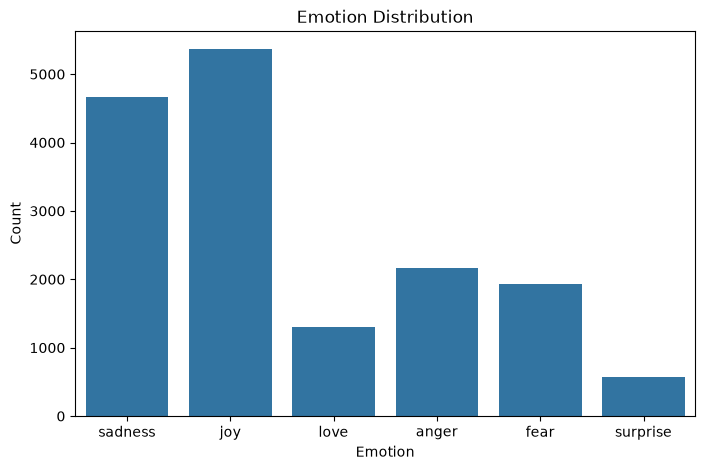

In [5]:
emotion_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=label_names,
    y=emotion_counts.values
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

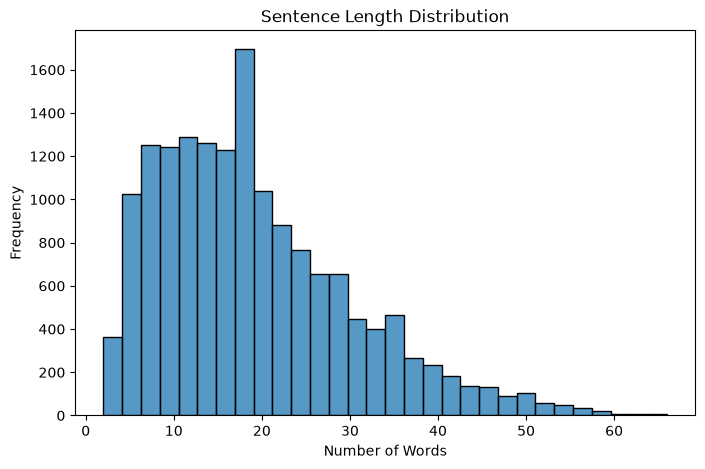

In [6]:
train_df["text_length"] = train_df["text"].apply(
    lambda x: len(x.split())
)

train_df["text_length"].describe()

plt.figure(figsize=(8,5))

sns.histplot(
    train_df["text_length"],
    bins=30
)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## Text Preprocessing

The following preprocessing steps are applied:

1. Lowercasing
2. URL Removal
3. Removal of Special Characters
4. Tokenization
5. Stopword Removal
6. Lemmatization

These steps help normalize the text and improve model performance.

In [7]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("never")


def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-z\s]",
        "",
        text
    )

    tokens = text.split()

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [8]:
sample = "I am VERY happy today!!!"

print("Original:")
print(sample)

print("\nProcessed:")
print(preprocess_text(sample))

Original:
I am VERY happy today!!!

Processed:
happy today


In [9]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)

valid_df["clean_text"] = valid_df["text"].apply(preprocess_text)

test_df["clean_text"] = test_df["text"].apply(preprocess_text)

## Feature Extraction using TF-IDF

Machine learning models cannot directly process text.

TF-IDF converts text into numerical vectors while emphasizing important words and reducing the influence of common words.

In [10]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(
    train_df["clean_text"]
)

X_valid = vectorizer.transform(
    valid_df["clean_text"]
)

X_test = vectorizer.transform(
    test_df["clean_text"]
)

y_train = train_df["label"]
y_valid = valid_df["label"]
y_test = test_df["label"]

In [11]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

nb_predictions = nb_model.predict(
    X_valid
)

nb_accuracy = accuracy_score(
    y_valid,
    nb_predictions
)

nb_f1 = f1_score(
    y_valid,
    nb_predictions,
    average="weighted"
)

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes F1:", nb_f1)

Naive Bayes Accuracy: 0.7515
Naive Bayes F1: 0.711616780080405


In [12]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_valid
)

lr_accuracy = accuracy_score(
    y_valid,
    lr_predictions
)

lr_f1 = f1_score(
    y_valid,
    lr_predictions,
    average="weighted"
)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression F1:", lr_f1)

Logistic Regression Accuracy: 0.8885
Logistic Regression F1: 0.8850072051641513


In [13]:
comparison_df = pd.DataFrame({

    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],

    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,Naive Bayes,0.7515,0.711617
1,Logistic Regression,0.8885,0.885007


In [14]:
best_model = lr_model

In [15]:
test_predictions = best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.90      0.95      0.93       581
         joy       0.85      0.96      0.90       695
        love       0.85      0.62      0.72       159
       anger       0.91      0.84      0.87       275
        fear       0.90      0.82      0.86       224
    surprise       0.89      0.48      0.63        66

    accuracy                           0.88      2000
   macro avg       0.88      0.78      0.82      2000
weighted avg       0.88      0.88      0.88      2000



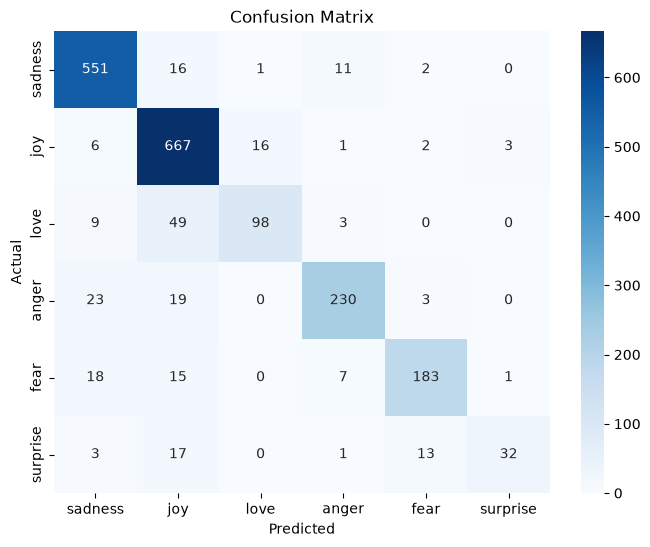

In [16]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
samples = [

    "I am extremely happy today.",

    "I feel lonely and hopeless.",

    "I am terrified of tomorrow.",

    "I love spending time with my family."
]

for text in samples:

    processed = preprocess_text(text)

    vector = vectorizer.transform(
        [processed]
    )

    prediction = best_model.predict(
        vector
    )[0]

    emotion = label_names[prediction]

    print(f"\nText: {text}")
    print(f"Predicted Emotion: {emotion}")


Text: I am extremely happy today.
Predicted Emotion: joy

Text: I feel lonely and hopeless.
Predicted Emotion: sadness

Text: I am terrified of tomorrow.
Predicted Emotion: fear

Text: I love spending time with my family.
Predicted Emotion: joy


# Conclusion

An AI-powered emotion detection system was successfully developed using Natural Language Processing techniques.

## Key Results

- Dataset: dair-ai/emotion
- TF-IDF used for feature extraction
- Two models were compared:
  - Naive Bayes
  - Logistic Regression
- Logistic Regression achieved the best performance.

## Final Performance

- Accuracy: 88.05%
- F1 Score: 87.58%

The model can successfully classify text into six emotions:

- Sadness
- Joy
- Love
- Anger
- Fear
- Surprise

This system can be applied in sentiment analysis, social media monitoring, customer feedback analysis, and conversational AI systems.